# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the dataset

In [3]:
data = pd.read_csv('.\\Datasets\\Preprocessed_dataset.csv')
data.head()

C:\Users\harsh\AppData\Local\Temp\ipykernel_25912\763181152.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('.\\Datasets\\Preprocessed_dataset.csv')


,Reporting Period,Project ID,Project County,Project City,Project ZIP,Gas Utility,Electric Utility,Project Completion Date,Total Project Cost,Pre-Retrofit Home Heating Fuel Type,...,Job Type,Type Of Dwelling,Measure Type,Estimated Annual kWh Savings,Estimated Annual MMBtu Savings,First Year Modeled Project Energy Savings $ Estimate,Year_Home_built_missing_flag,size_of_home_flag,Location_1_latitude,Location_1_Longitude
0,2023-06-30,577366,Broome,Endicott,13760,New York State Electric & Gas,New York State Electric & Gas,2023-06-22,9661.0,Oil,...,Home Performance,Single Family,Building Shell,277.0,24.0,6.826545,2,0,42.110115,-76.032545
1,2023-06-30,581070,Queens,Queens,11433,National Grid,Consolidated Edison,2023-06-22,11867.0,Natural Gas,...,Home Performance,Single Family,Building Shell,1062.0,66.0,7.221105,2,0,40.697715,-73.786045
2,2023-06-30,570945,Oswego,Fulton,13069,National Grid,National Grid,2023-06-20,9998.0,Natural Gas,...,Home Performance,Single Family,Building Shell,59.0,60.0,6.489205,2,0,43.325035,-76.41174
3,2023-06-30,571921,St. Lawrence,Nicholville,12965,Saint Lawrence Gas,National Grid,2023-06-13,6880.0,Oil,...,Home Performance,Single Family,Building Shell,482.0,15.0,6.445720,2,0,44.695165,-74.704765
4,2023-06-30,555646,Oswego,Cleveland,13042,National Grid,National Grid,2023-06-13,12289.0,Oil,...,Home Performance,Single Family,Building Shell,690.0,78.0,7.490529,2,0,43.2312547,-75.8681922


In [4]:
data.shape

(51934, 23)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51934 entries, 0 to 51933
Data columns (total 23 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Reporting Period                                      51934 non-null  object 
 1   Project ID                                            51934 non-null  object 
 2   Project County                                        51934 non-null  object 
 3   Project City                                          51934 non-null  object 
 4   Project ZIP                                           51934 non-null  int64  
 5   Gas Utility                                           51934 non-null  object 
 6   Electric Utility                                      51934 non-null  object 
 7   Project Completion Date                               51934 non-null  object 
 8   Total Project Cost                                    51

In [6]:
data.describe()

,Project ZIP,Total Project Cost,Year Home Built,Size Of Home,Number Of Units,Estimated Annual kWh Savings,Estimated Annual MMBtu Savings,First Year Modeled Project Energy Savings $ Estimate,Year_Home_built_missing_flag,size_of_home_flag
count,51934.000000,51934.000000,51934.000000,51934.000000,51934.000000,51934.000000,51934.000000,51930.000000,51934.000000,51934.0
mean,13263.577695,6432.440848,1953.205723,1572.731717,1.058074,469.881330,31.389013,5.853971,1.200350,0.0
std,1300.423594,4154.131692,23.418304,627.668989,2.175599,1095.349244,27.025809,0.875141,0.979409,0.0
min,10001.000000,129.000000,1800.000000,800.000000,1.000000,-23368.000000,-80.000000,0.000000,0.000000,0.0
25%,12458.000000,3742.000000,1955.000000,1111.000000,1.000000,158.000000,14.000000,5.356586,0.000000,0.0
50%,13492.000000,5926.000000,1955.000000,1440.000000,1.000000,443.000000,26.000000,5.957131,2.000000,0.0
75%,14424.000000,8462.000000,1955.000000,1874.000000,1.000000,536.000000,43.000000,6.444131,2.000000,0.0
max,14905.000000,92297.000000,2022.000000,4000.000000,396.000000,38572.000000,1005.000000,10.199547,2.000000,0.0


# EDA

## Univariate Analysis

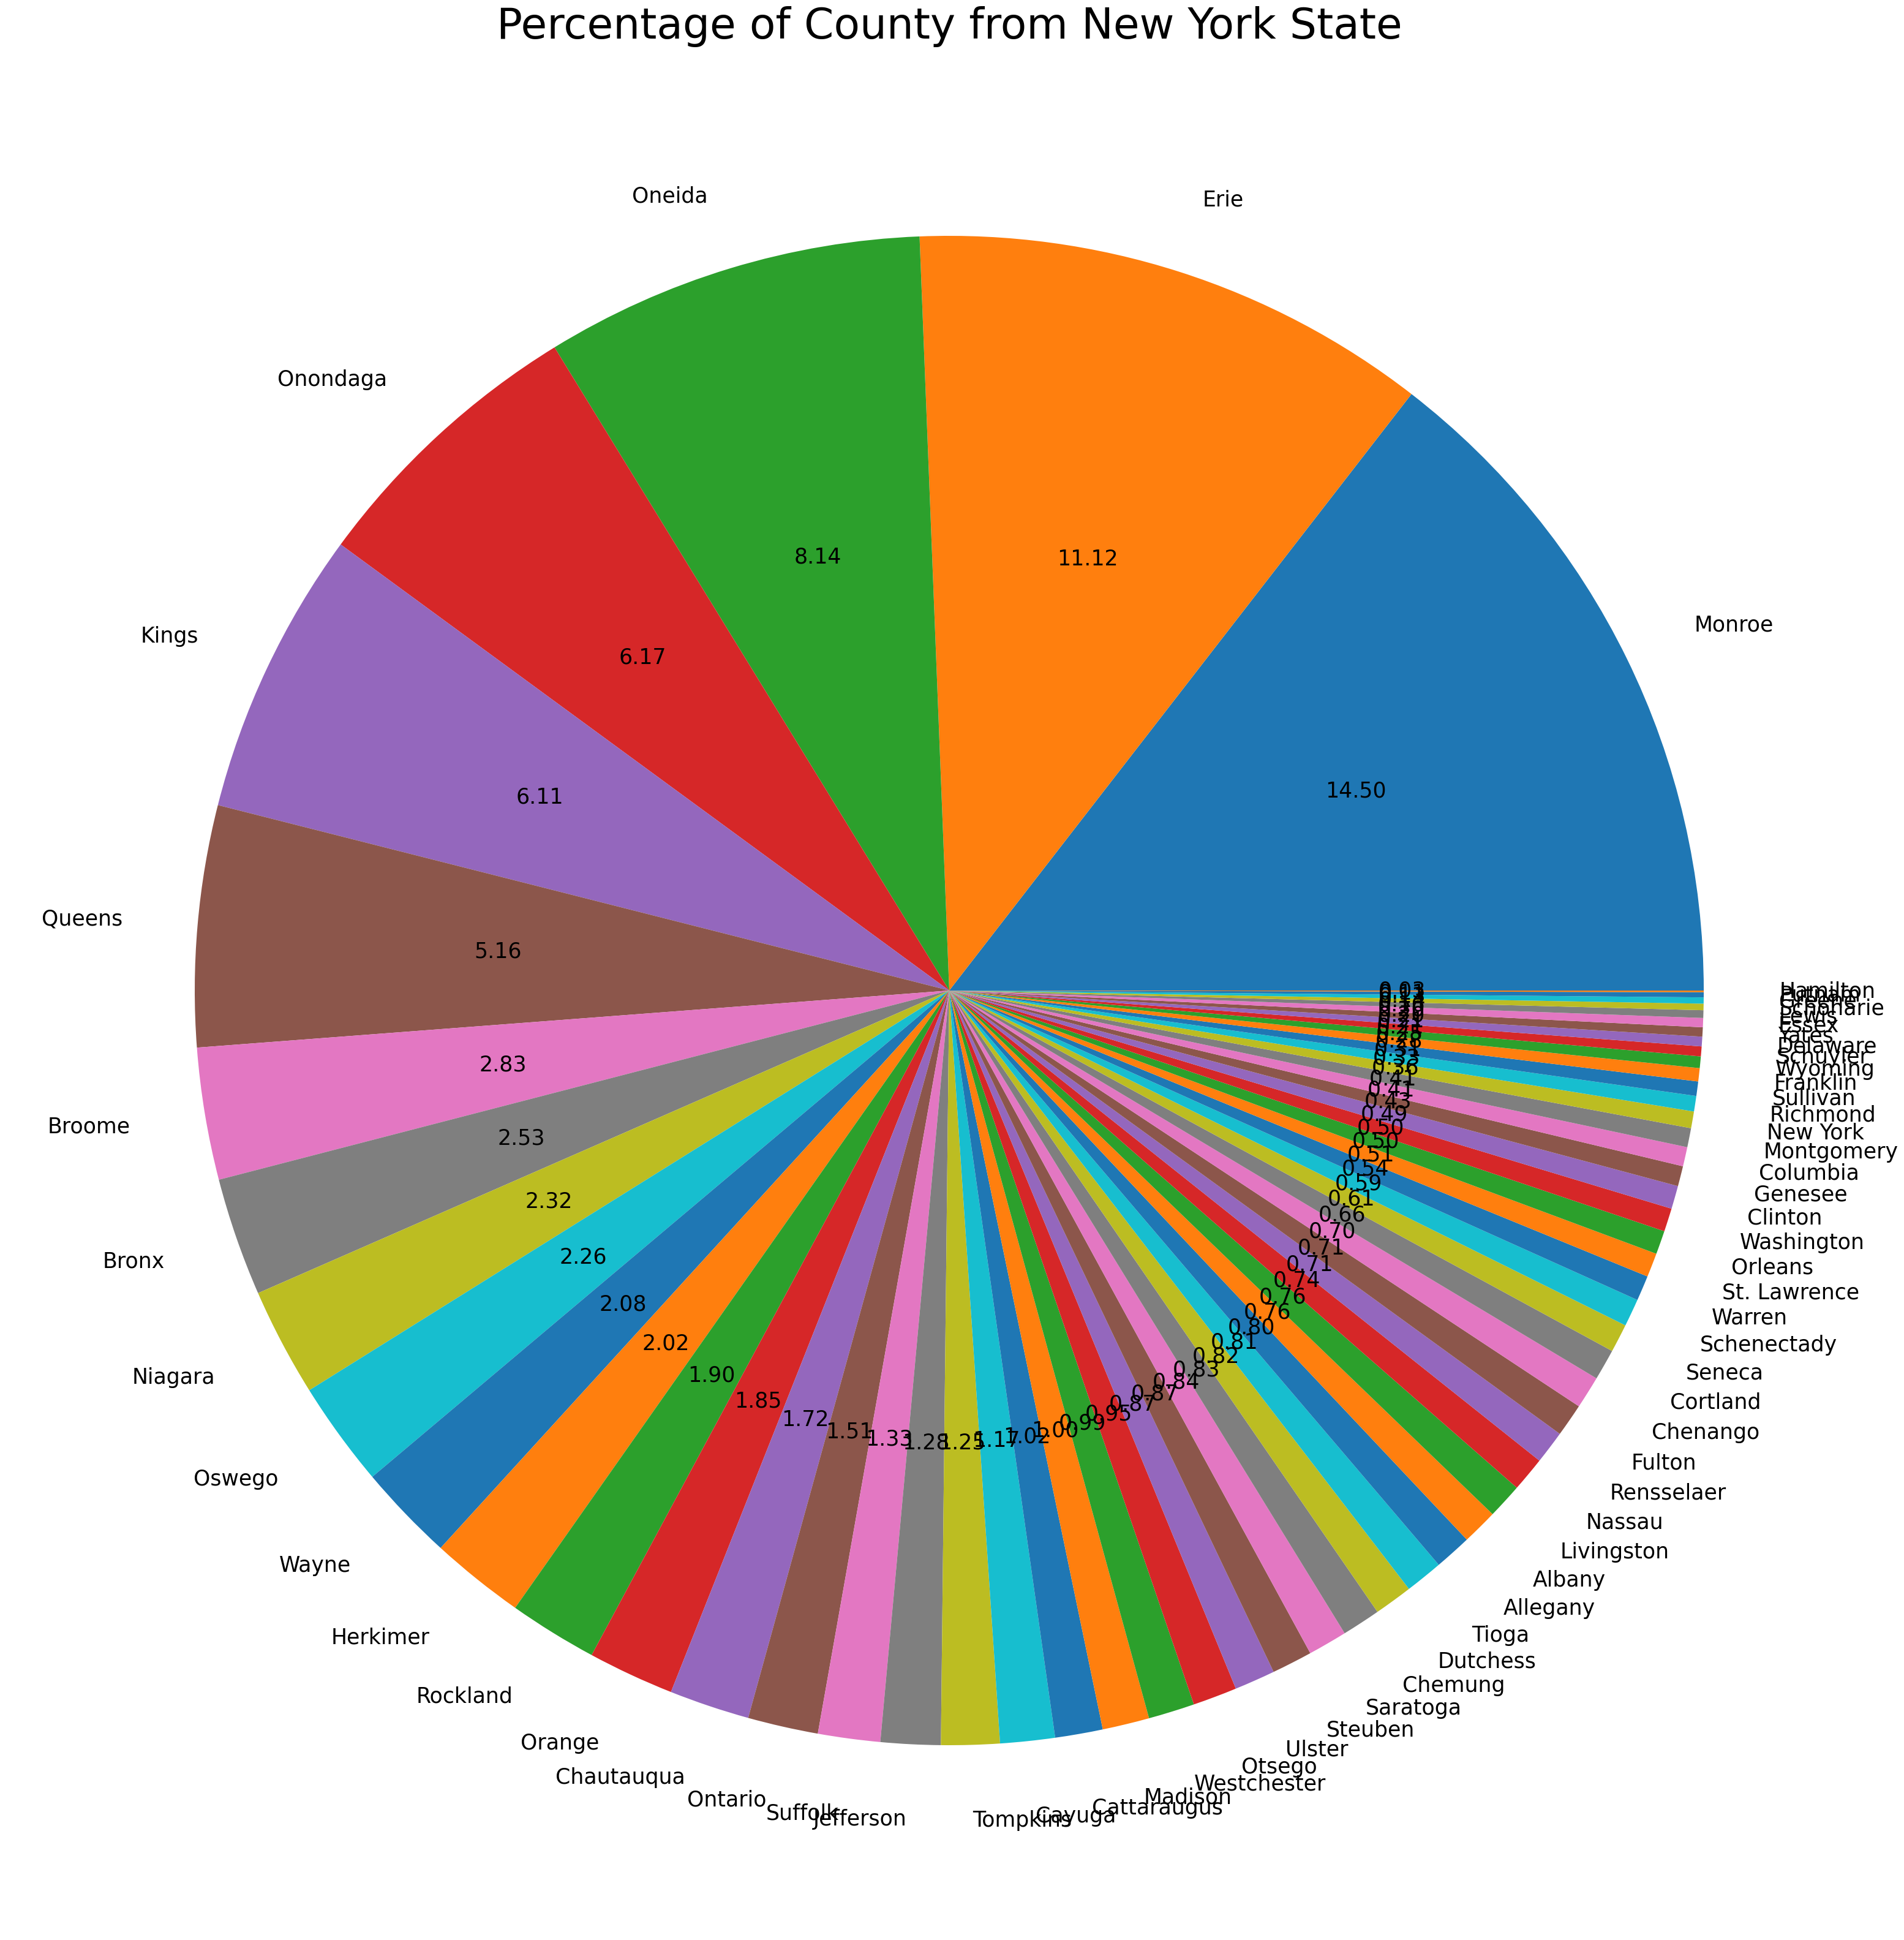

In [ ]:
county_count = data['Project County'].value_counts()
plt.figure(figsize=(40,40))
plt.pie(county_count, labels= county_count.index, autopct= "%.2f", textprops={'fontsize': 25})
plt.title("Percentage of County from New York State", fontsize = "50")
plt.xticks(rotation =45)
plt.show()

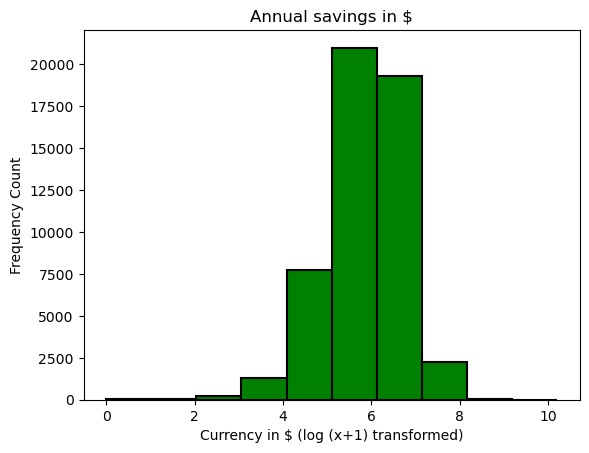

In [ ]:
plt.hist(data['First Year Modeled Project Energy Savings $ Estimate'], color="green" , edgecolor='black', linewidth=1.5)
plt.title("Annual savings in $")
plt.xlabel("Currency in $ (log (x+1) transformed)")
plt.ylabel("Frequency Count")

plt.show()

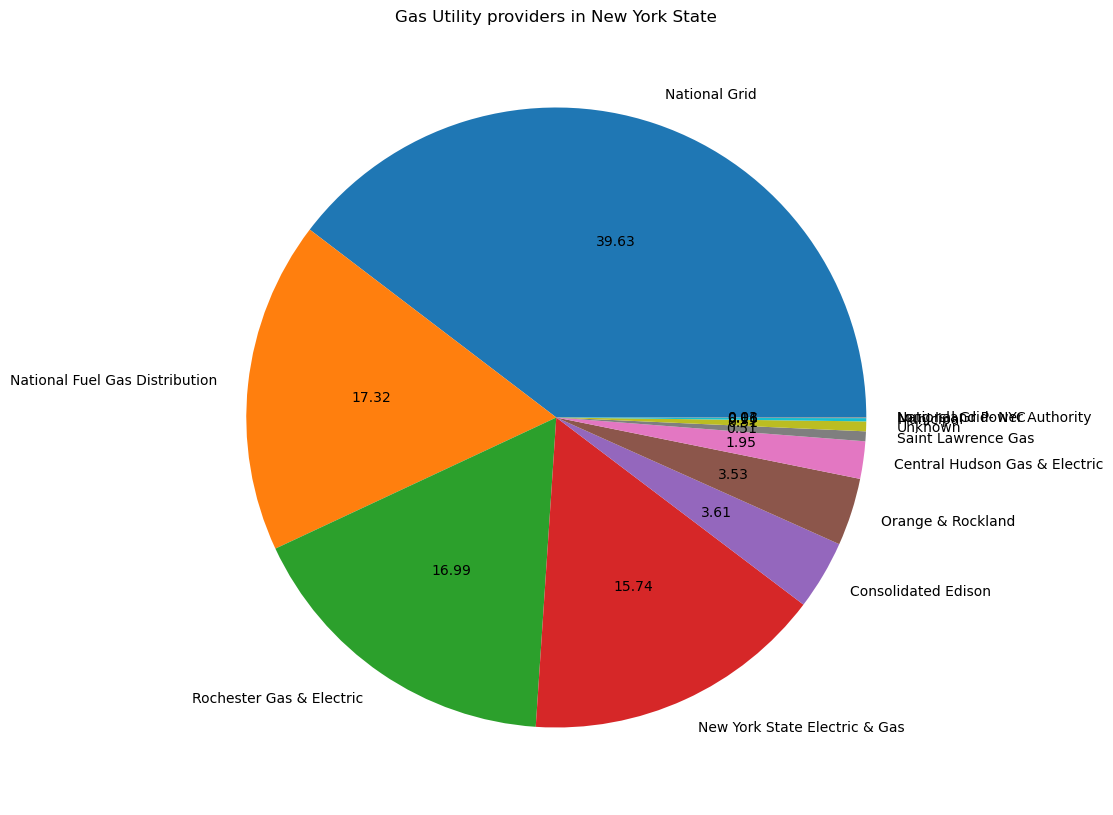

In [ ]:
gau_utils = data['Gas Utility'].value_counts()

plt.figure(figsize=(10,30))
plt.pie(gau_utils, labels=gau_utils.index, autopct="%.2f")
plt.title("Gas Utility providers in New York State")
plt.show()

In [ ]:
data['Gas Utility'].value_counts()

Gas Utility
National Grid                     20584
National Fuel Gas Distribution     8993
Rochester Gas & Electric           8825
New York State Electric & Gas      8176
Consolidated Edison                1877
Orange & Rockland                  1831
Central Hudson Gas & Electric      1012
Saint Lawrence Gas                  266
Unknown                             266
Municipal                            85
Long Island Power Authority          13
National Grid- NYC                    6
Name: count, dtype: int64

In [ ]:
gas = data[data['Electric Utility']=="Municipal"].groupby(["Project County", "Electric Utility","Gas Utility"])['Project ID'].count()
print(gas)

Project County  Electric Utility  Gas Utility                   
Albany          Municipal         National Grid                       2
Allegany        Municipal         Municipal                           1
                                  National Fuel Gas Distribution     43
Broome          Municipal         New York State Electric & Gas      14
Cattaraugus     Municipal         Municipal                           2
                                  National Fuel Gas Distribution     39
                                  New York State Electric & Gas       1
Chautauqua      Municipal         Municipal                           7
                                  National Fuel Gas Distribution    253
                                  National Grid                       2
Chenango        Municipal         Unknown                            14
Clinton         Municipal         Municipal                           6
                                  New York State Electric & Gas       1

##### Findings 1
 The Gas Utility still has unknown entity has we are unable to create a relationship using our pipeline county->electric utility -> mode(Gas utility) for specific counties

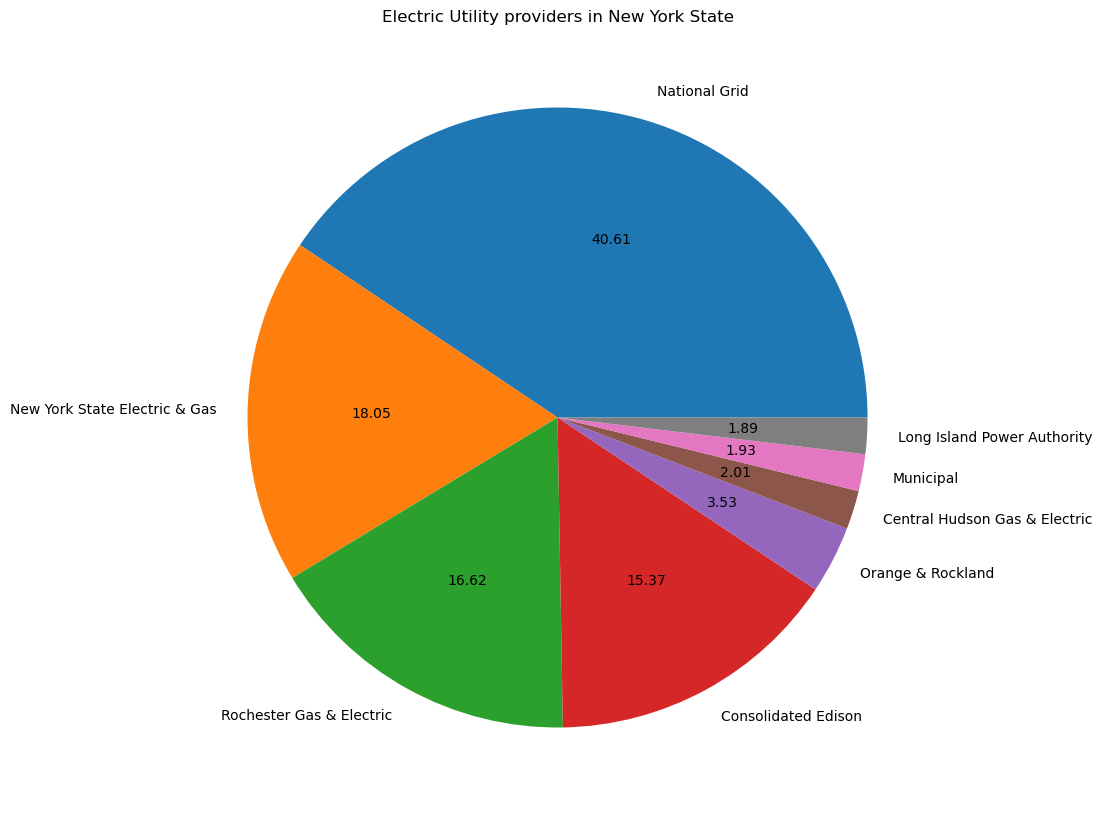

In [ ]:
elec_utils = data['Electric Utility'].value_counts()

plt.figure(figsize=(10,30))
plt.pie(elec_utils, labels=elec_utils.index, autopct="%.2f")
plt.title("Electric Utility providers in New York State")
plt.show()

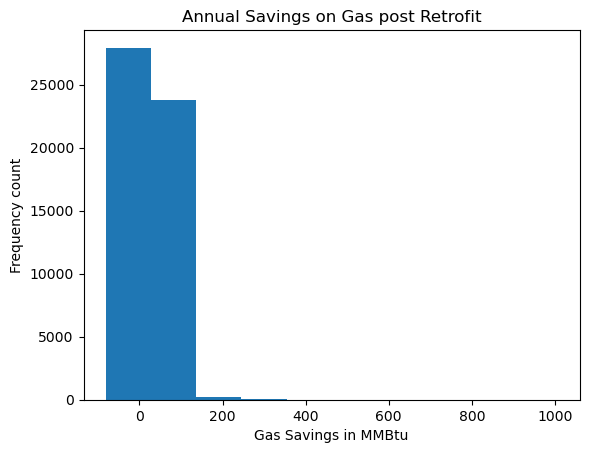

In [ ]:
plt.hist(data['Estimated Annual MMBtu Savings'])
plt.title("Annual Savings on Gas post Retrofit")
plt.xlabel("Gas Savings in MMBtu")
plt.ylabel("Frequency count")
plt.show()

### Findings 2

The Estimated Annual MMBtu Savings is left skewed with long right tail, which tells that any large value which dominate the loss function, we perform log(x+1) transformation to assume that the data points are normal distributed which would result more reliable and stable for the model

### *Need to work on this*

can not apply log transformation as there are negative savings, need to transform in a way where we can normal distribute the data

### Proposed Solution

Use **Yeo-Johnson transformation** for columns that contain negative and positive values.
Unlike log transformation, Yeo-Johnson can handle zero and negative values while reducing skewness.

```python
from sklearn.preprocessing import PowerTransformer
from scipy.stats import skew
import matplotlib.pyplot as plt

col_name = 'Estimated Annual MMBtu Savings'
x = data[[col_name]].copy()

# Yeo-Johnson works with negative values and helps normalize skewed data
pt = PowerTransformer(method='yeo-johnson', standardize=False)
data[col_name + ' (YJ)'] = pt.fit_transform(x)

print('Skewness before:', skew(data[col_name], nan_policy='omit'))
print('Skewness after :', skew(data[col_name + ' (YJ)'], nan_policy='omit'))

plt.figure(figsize=(10, 6))
plt.hist(data[col_name + ' (YJ)'], color='green', edgecolor='black', linewidth=1.5, bins=30)
plt.title('Distribution after Yeo-Johnson Transformation', fontsize=14)
plt.xlabel(col_name + ' (YJ)', fontsize=12)
plt.ylabel('Frequency Count', fontsize=12)
plt.show()
```

If skewness is still high, we can cap extreme outliers (winsorization) before applying the transformation.

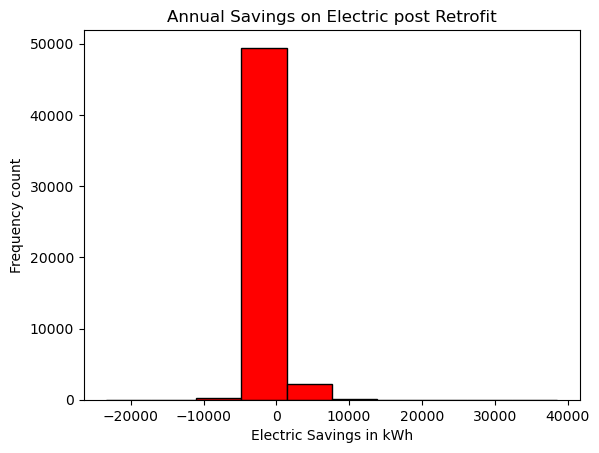

In [ ]:
plt.hist(data['Estimated Annual kWh Savings'], color  ="red", edgecolor ="black")
plt.title("Annual Savings on Electric post Retrofit")
plt.xlabel("Electric Savings in kWh")
plt.ylabel("Frequency count")
plt.show()

In [ ]:
from scipy.stats import skew, kurtosis

col = data['Estimated Annual kWh Savings']

print("Skewness:", skew(col, nan_policy='omit'))
print("Kurtosis:", kurtosis(col, nan_policy='omit'))

Skewness: 4.7923468379033505
Kurtosis: 194.62456740041299


### Findings 3
the value is skewed, the graph has a sharp rise at close to zero and have no proper distribution around it which larger values expanding the axis

### *Need to work on the above skewness*

In [ ]:
def hist_plot(x):
    title = x
    plt.figure(figsize=(20,20))
    plt.hist(data[x], edgecolor ="black", bins = 10)
    plt.title(f"The distribution plot of {title}")
    plt.show()

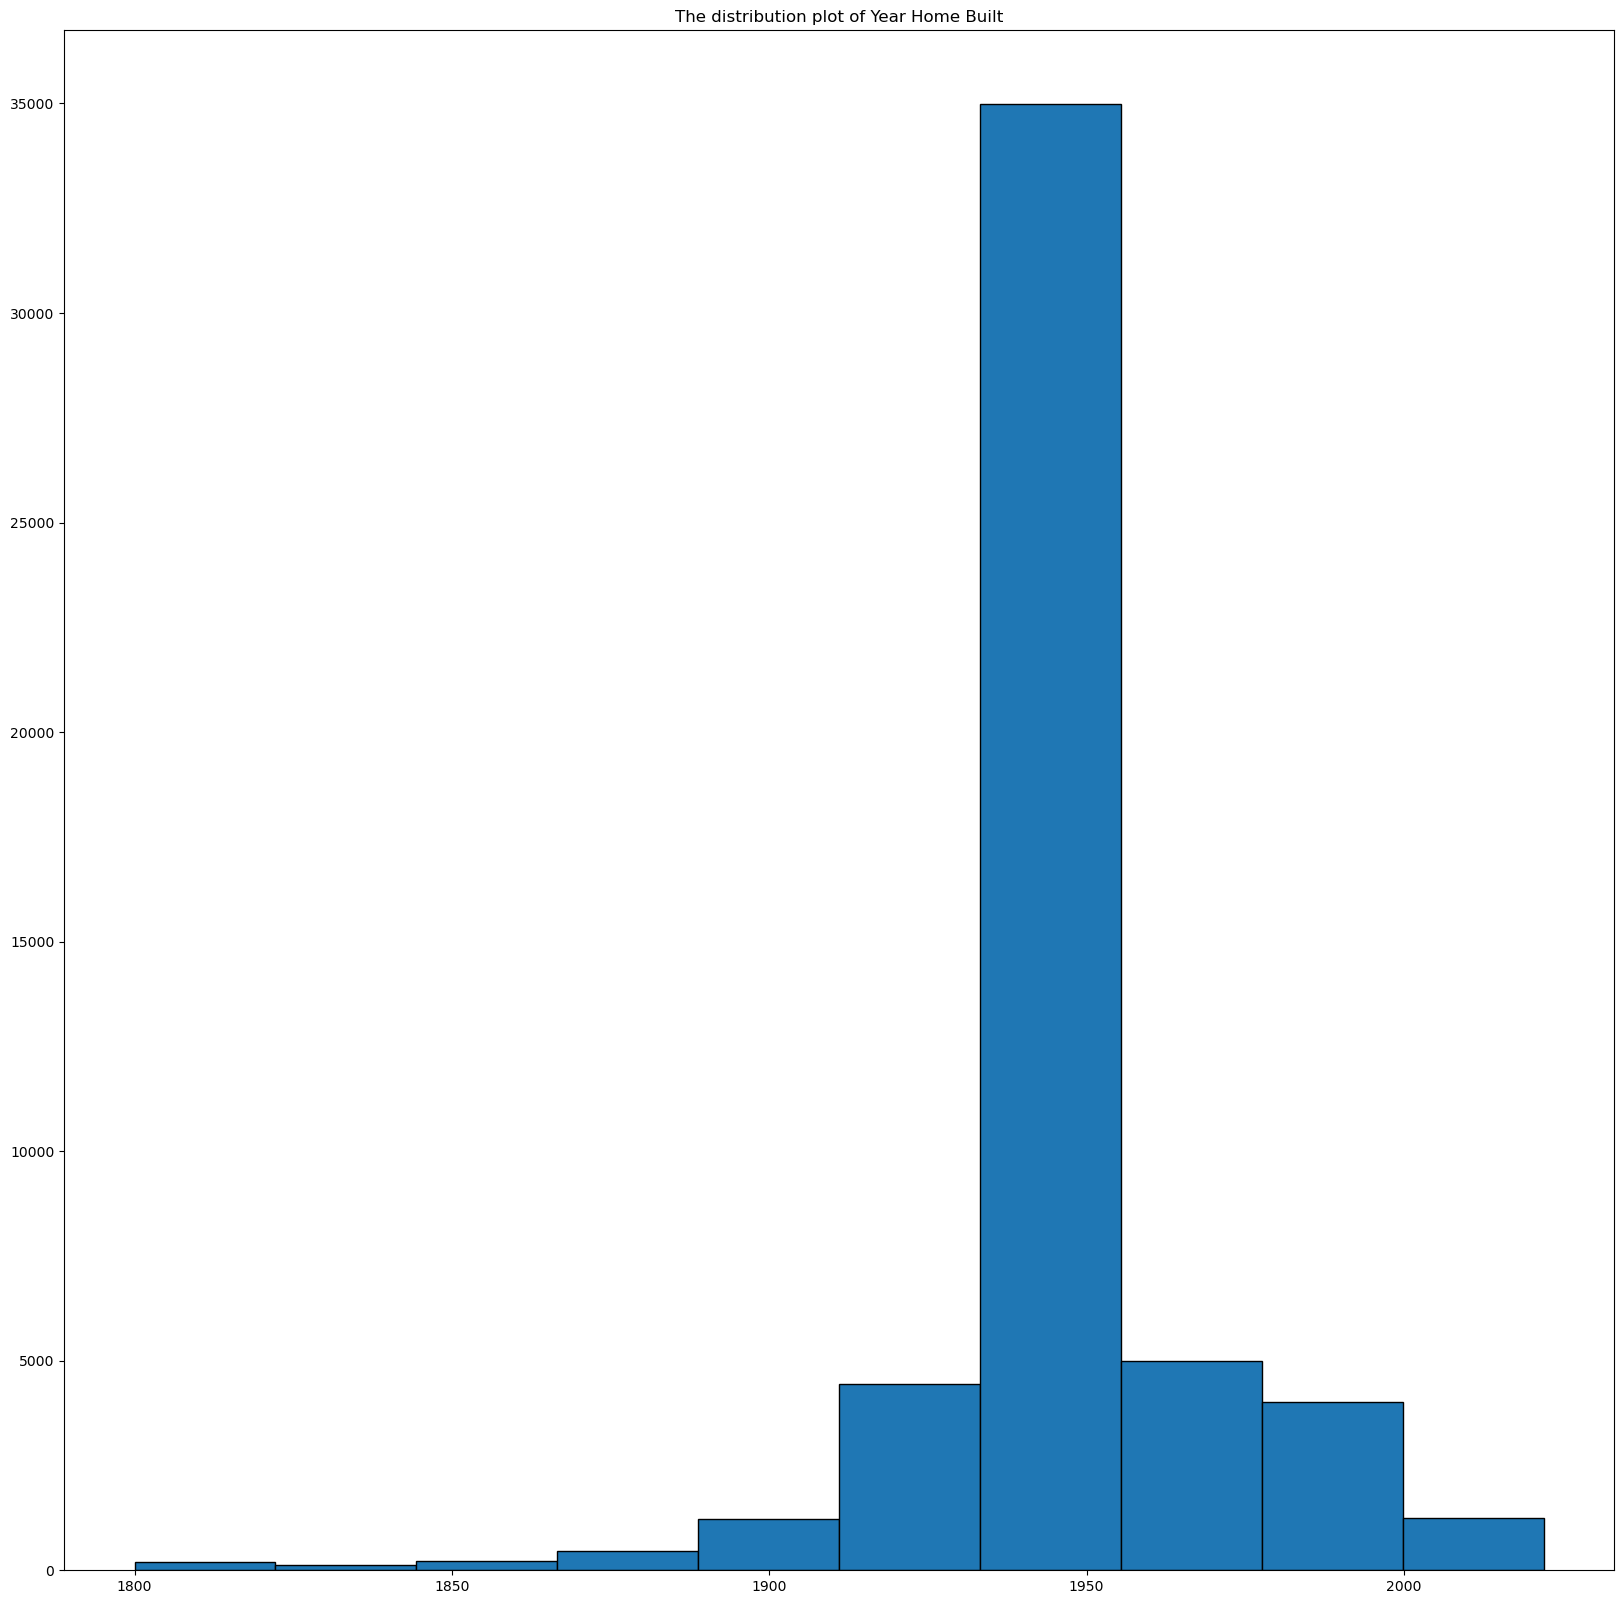

In [ ]:
hist_plot("Year Home Built")

### Finding 5
The data shows that the predominant house which are part of the retrofit program are built between 1900 and 2000

## Bivariate Analysis

In [ ]:
def bar_plot(x,y):
    data_x = x
    data_y = y
    plt.figure(figsize=(10,10))
    plt.bar(data[data_x], data[data_y])
    plt.title(f" {data_x} v/s {data_y}")
    plt.xlabel(f"{data_x}")
    plt.ylabel(f"{data_y}")
    plt.show()

In [ ]:
data.columns

Index(['Reporting Period', 'Project ID', 'Project County', 'Project City',
       'Project ZIP', 'Gas Utility', 'Electric Utility',
       'Project Completion Date', 'Total Project Cost',
       'Pre-Retrofit Home Heating Fuel Type', 'Year Home Built',
       'Size Of Home', 'Number Of Units', 'Job Type', 'Type Of Dwelling',
       'Measure Type', 'Estimated Annual kWh Savings',
       'Estimated Annual MMBtu Savings',
       'First Year Modeled Project Energy Savings $ Estimate',
       'Year_Home_built_missing_flag', 'size_of_home_flag',
       'Location_1_latitude', 'Location_1_Longitude'],
      dtype='object')

Text(0.5, 0, 'Project cost')

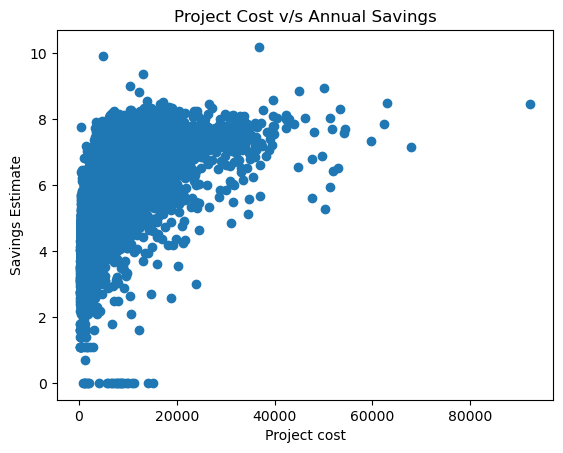

In [ ]:
plt.scatter(data['Total Project Cost'], data['First Year Modeled Project Energy Savings $ Estimate'])
plt.title("Project Cost v/s Annual Savings")
plt.ylabel("Savings Estimate")
plt.xlabel("Project cost")

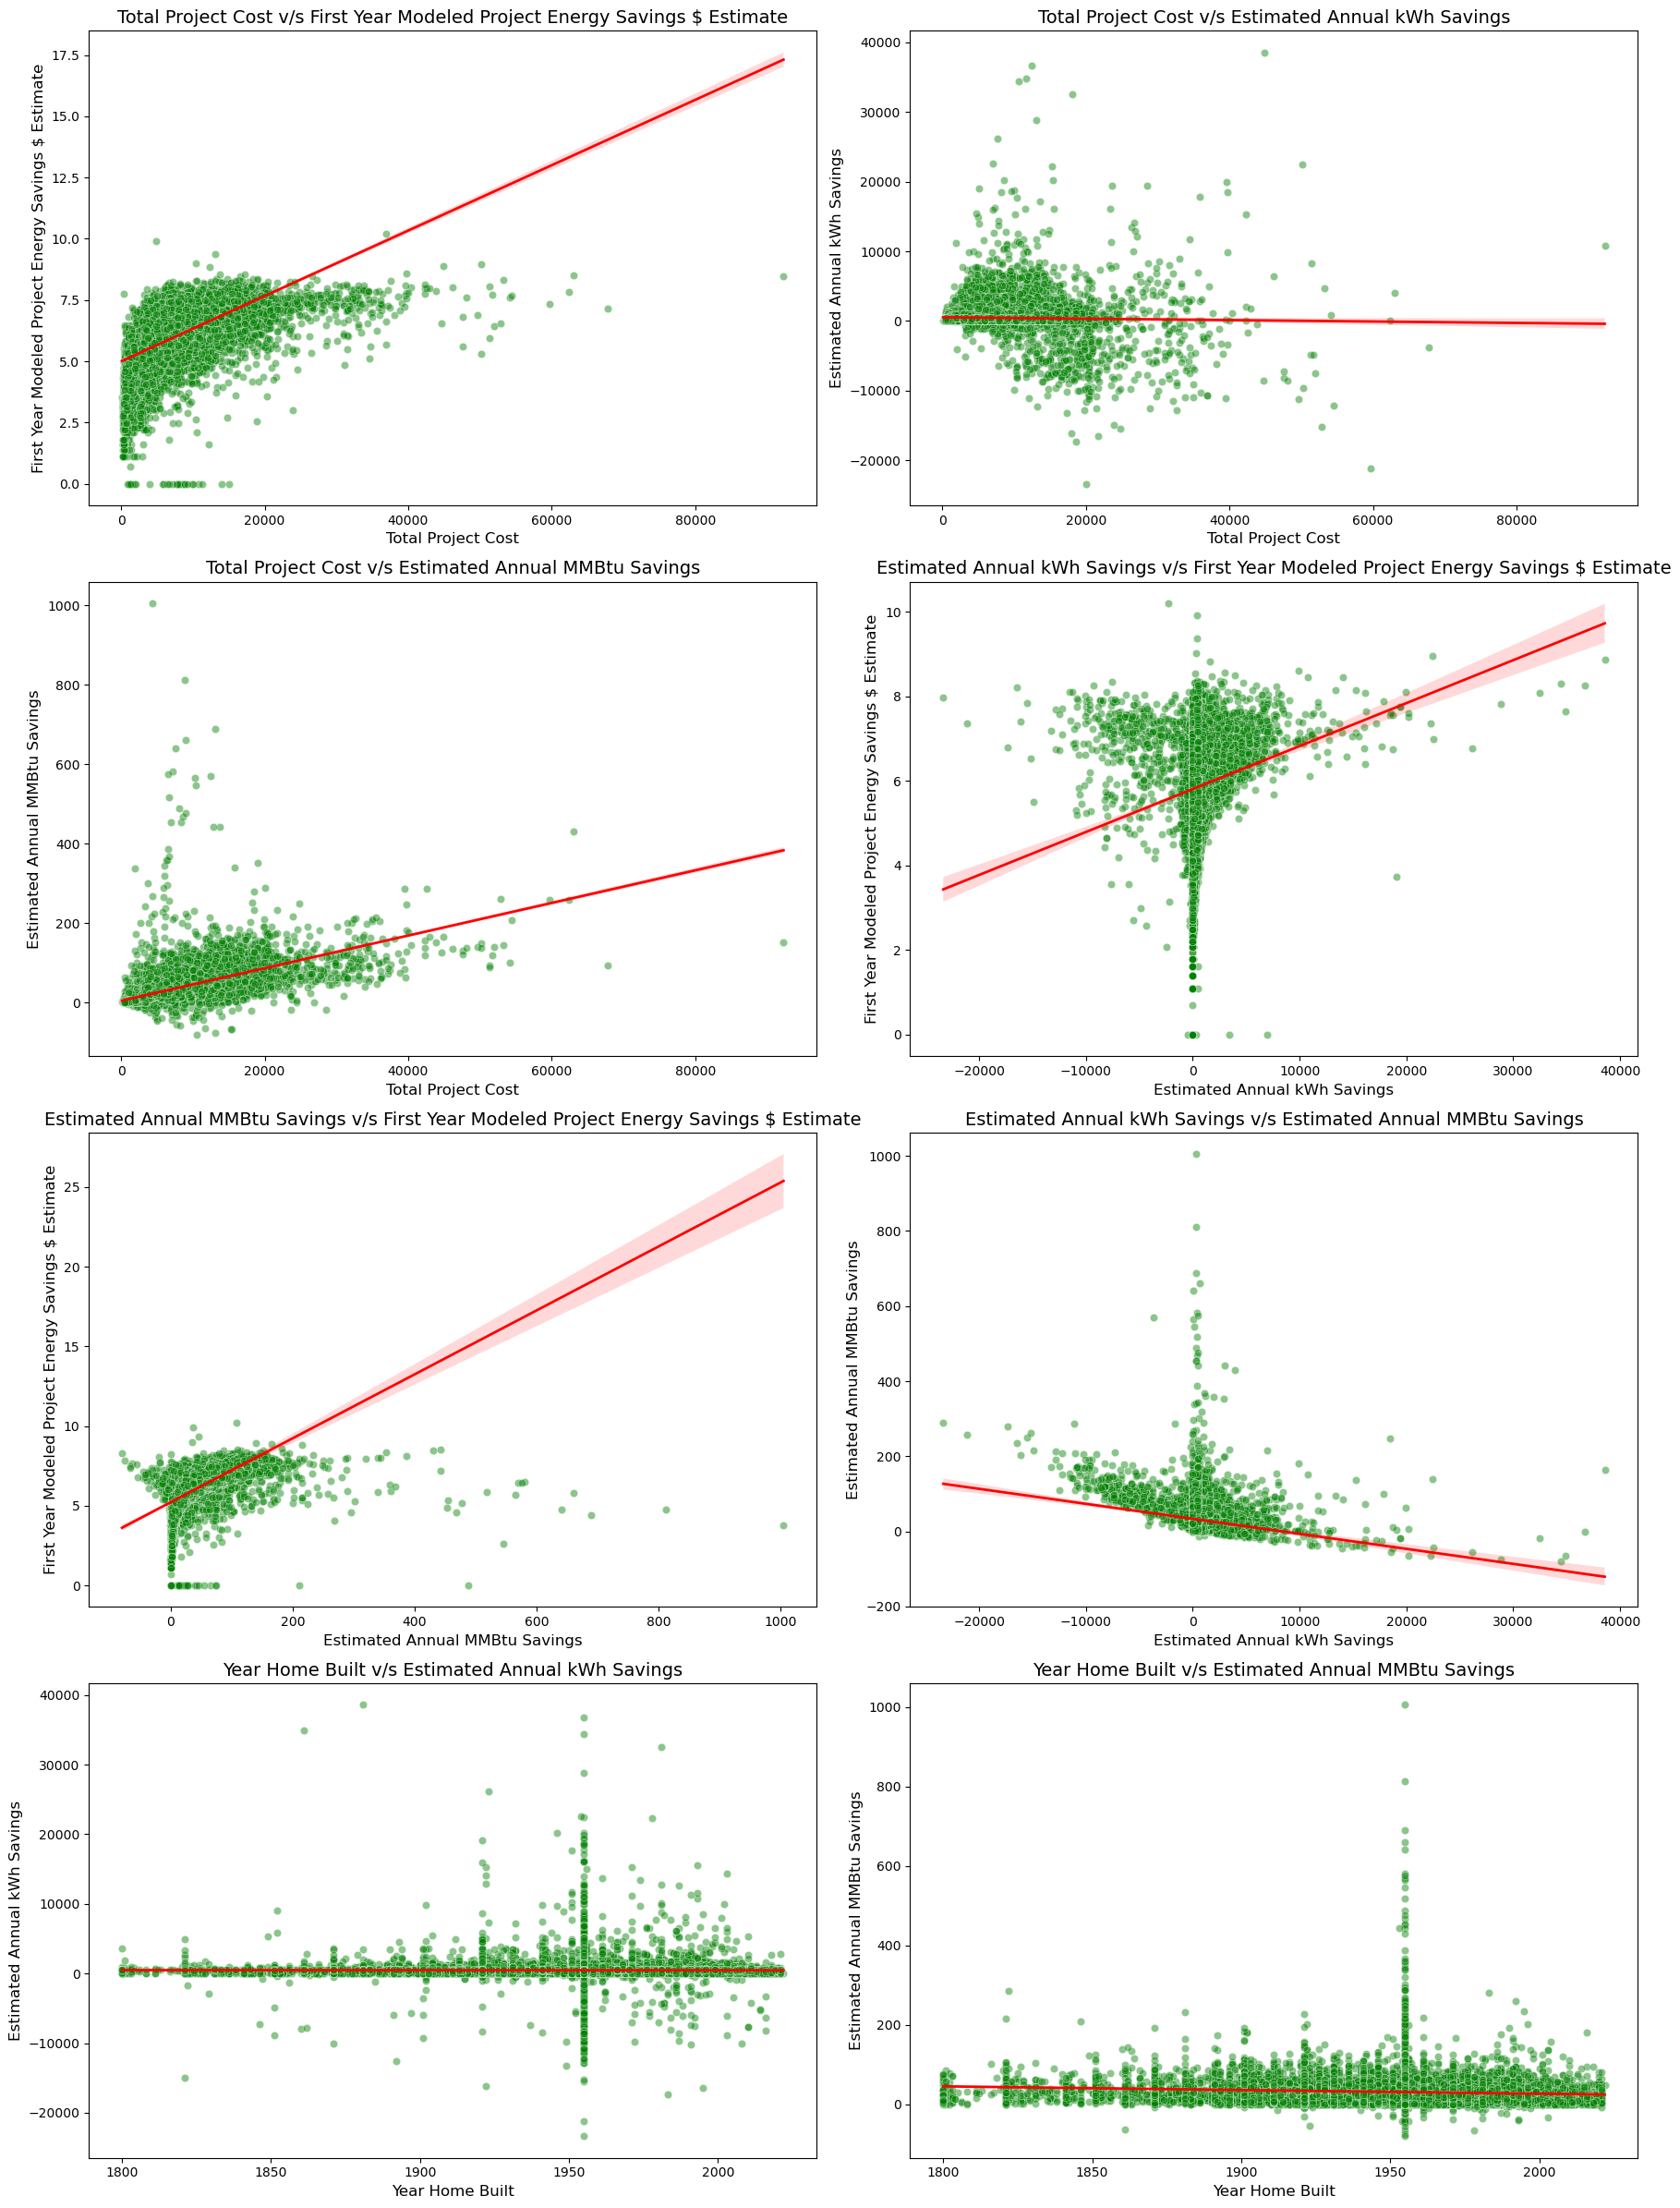

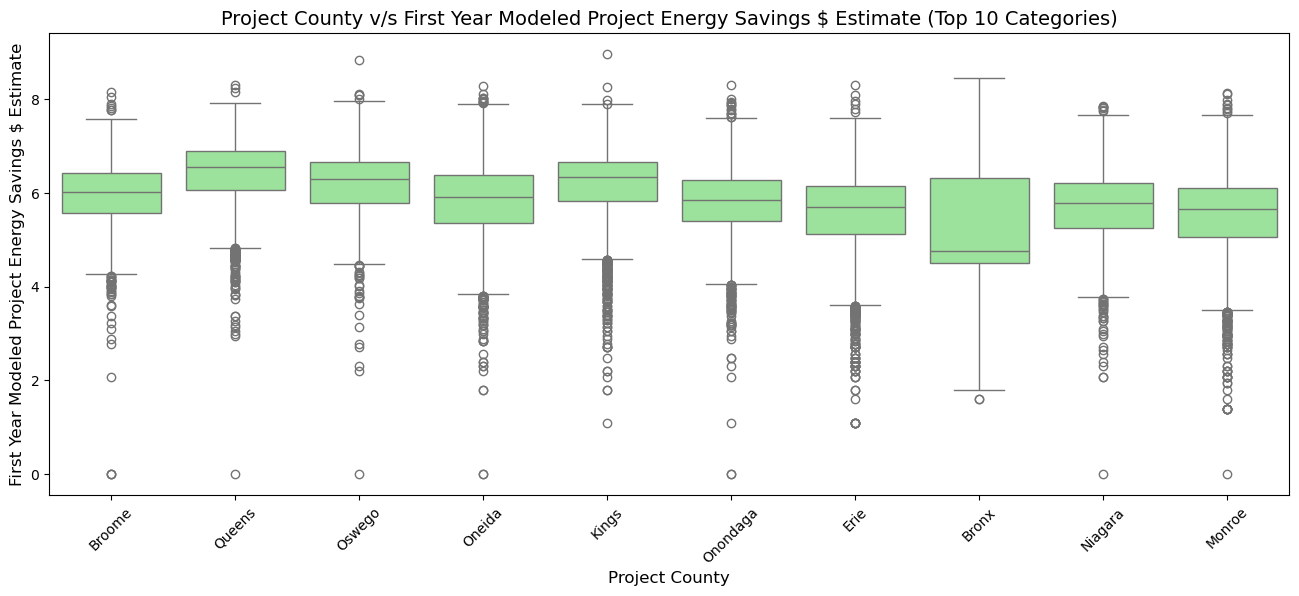

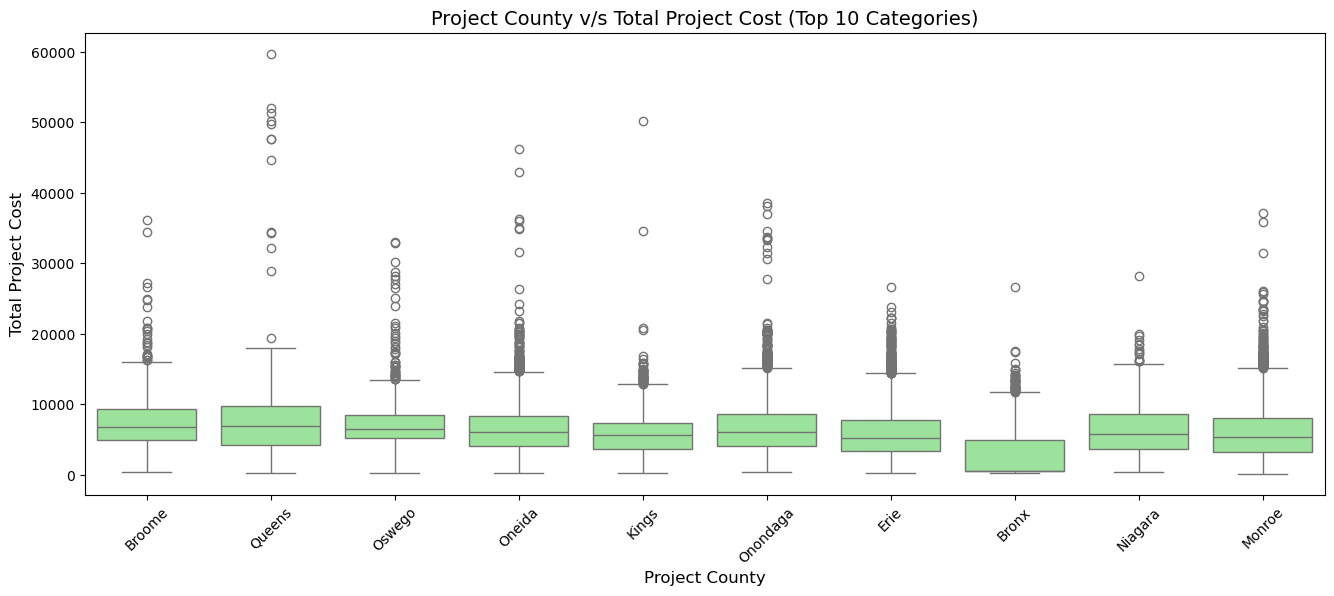

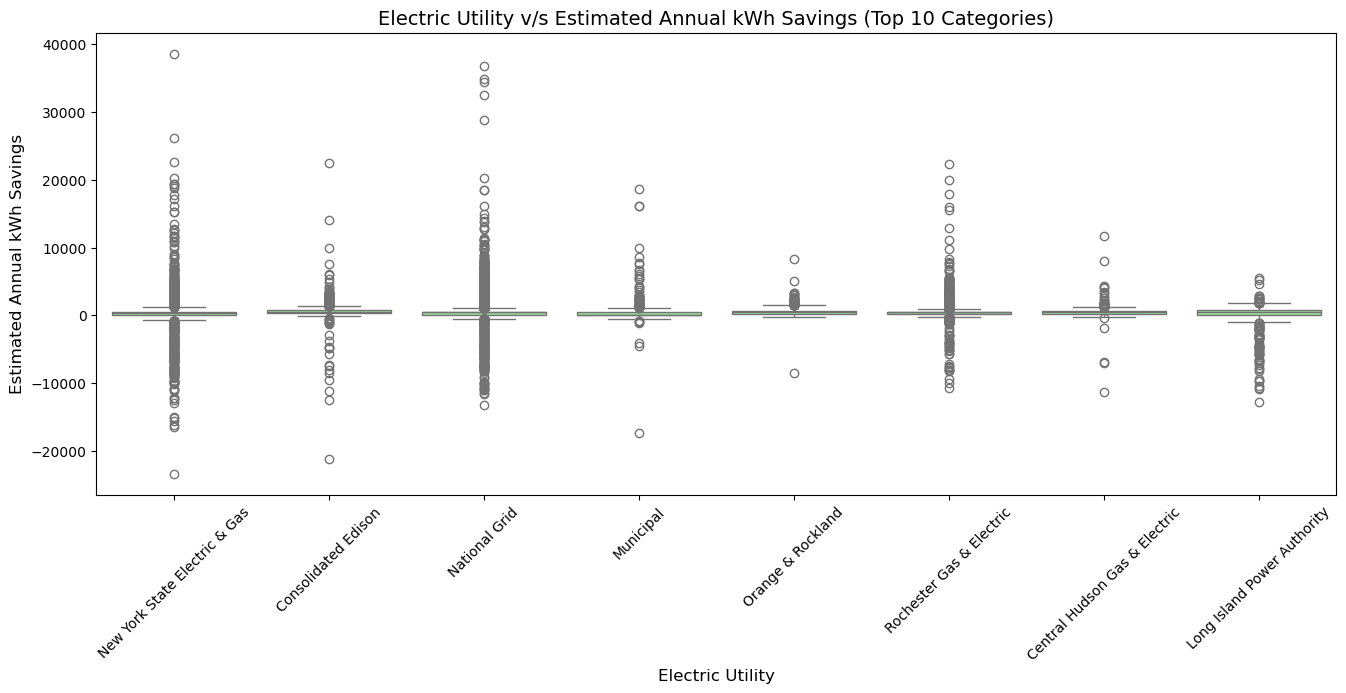

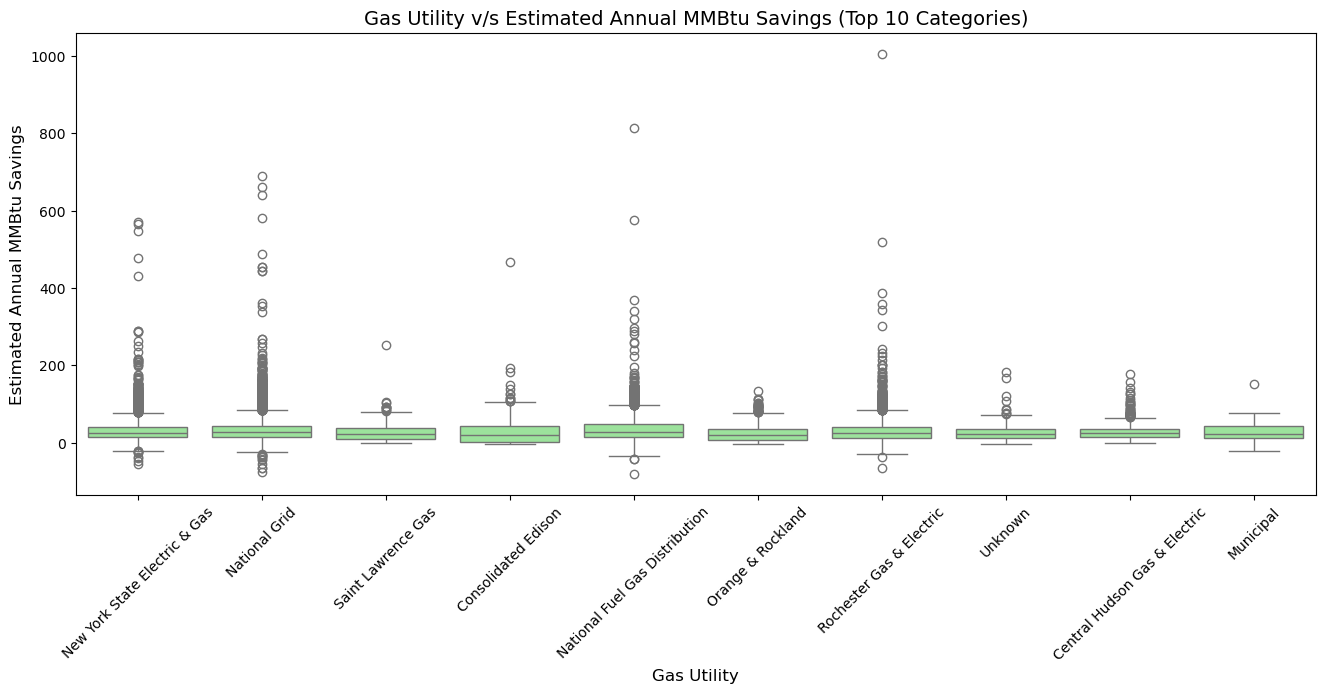

,Check,Count
10,IQR outliers in Estimated Annual kWh Savings,4943
11,IQR outliers in Estimated Annual MMBtu Savings,1529
8,IQR outliers in Total Project Cost,1228
1,Negative values in Estimated Annual kWh Savings,1157
9,IQR outliers in First Year Modeled Project Ene...,913
7,Unknown/missing-like labels in Gas Utility,266
4,Duplicate Project ID records,127
2,Negative values in Estimated Annual MMBtu Savings,123
0,Negative values in First Year Modeled Project ...,0
3,Zero/negative values in Total Project Cost,0


In [7]:
# Comprehensive Bivariate Analysis and Data Inconsistency Checks

# 1) Numeric vs Numeric meaningful comparisons
candidate_pairs = [
    ('Total Project Cost', 'First Year Modeled Project Energy Savings $ Estimate'),
    ('Total Project Cost', 'Estimated Annual kWh Savings'),
    ('Total Project Cost', 'Estimated Annual MMBtu Savings'),
    ('Estimated Annual kWh Savings', 'First Year Modeled Project Energy Savings $ Estimate'),
    ('Estimated Annual MMBtu Savings', 'First Year Modeled Project Energy Savings $ Estimate'),
    ('Estimated Annual kWh Savings', 'Estimated Annual MMBtu Savings'),
    ('Year Home Built', 'Estimated Annual kWh Savings'),
    ('Year Home Built', 'Estimated Annual MMBtu Savings')
]

valid_pairs = [pair for pair in candidate_pairs if pair[0] in data.columns and pair[1] in data.columns]

if len(valid_pairs) > 0:
    n = len(valid_pairs)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 6 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, (x, y) in zip(axes, valid_pairs):
        plot_df = data[[x, y]].dropna()
        sns.scatterplot(data=plot_df, x=x, y=y, color='green', alpha=0.45, ax=ax)
        sns.regplot(data=plot_df, x=x, y=y, scatter=False, color='red', line_kws={'linewidth': 2}, ax=ax)
        ax.set_title(f'{x} v/s {y}', fontsize=14)
        ax.set_xlabel(x, fontsize=12)
        ax.set_ylabel(y, fontsize=12)

    for ax in axes[len(valid_pairs):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print('No valid numeric-numeric pairs found in the dataset.')


# 2) Category vs Numeric meaningful comparisons (Top categories only for readability)
cat_num_candidates = [
    ('Project County', 'First Year Modeled Project Energy Savings $ Estimate'),
    ('Project County', 'Total Project Cost'),
    ('Electric Utility', 'Estimated Annual kWh Savings'),
    ('Gas Utility', 'Estimated Annual MMBtu Savings')
]

for cat_col, num_col in cat_num_candidates:
    if cat_col in data.columns and num_col in data.columns:
        plot_df = data[[cat_col, num_col]].dropna().copy()
        top_categories = plot_df[cat_col].value_counts().head(10).index
        plot_df = plot_df[plot_df[cat_col].isin(top_categories)]

        plt.figure(figsize=(16, 6))
        sns.boxplot(data=plot_df, x=cat_col, y=num_col, color='lightgreen')
        plt.title(f'{cat_col} v/s {num_col} (Top 10 Categories)', fontsize=14)
        plt.xlabel(cat_col, fontsize=12)
        plt.ylabel(num_col, fontsize=12)
        plt.xticks(rotation=45)
        plt.show()


# 3) Inconsistency checks to track and work on later
inconsistency_report = []

# Negative value checks for savings columns
savings_cols = [
    'First Year Modeled Project Energy Savings $ Estimate',
    'Estimated Annual kWh Savings',
    'Estimated Annual MMBtu Savings'
]
for col in savings_cols:
    if col in data.columns:
        inconsistency_report.append({
            'Check': f'Negative values in {col}',
            'Count': int((data[col] < 0).sum())
        })

# Non-positive project cost check
if 'Total Project Cost' in data.columns:
    inconsistency_report.append({
        'Check': 'Zero/negative values in Total Project Cost',
        'Count': int((data['Total Project Cost'] <= 0).sum())
    })

# Duplicate Project ID check
if 'Project ID' in data.columns:
    inconsistency_report.append({
        'Check': 'Duplicate Project ID records',
        'Count': int(data['Project ID'].duplicated().sum())
    })

# Missing/unknown string category checks
unknown_tokens = {'', 'unknown', 'unk', 'n/a', 'na', 'none', 'nan', 'null'}
for col in ['Project County', 'Electric Utility', 'Gas Utility']:
    if col in data.columns:
        series = data[col].astype(str).str.strip().str.lower()
        inconsistency_report.append({
            'Check': f'Unknown/missing-like labels in {col}',
            'Count': int(series.isin(unknown_tokens).sum())
        })

# IQR outlier checks for key numeric columns
key_numeric_cols = [
    'Total Project Cost',
    'First Year Modeled Project Energy Savings $ Estimate',
    'Estimated Annual kWh Savings',
    'Estimated Annual MMBtu Savings'
]
for col in key_numeric_cols:
    if col in data.columns:
        temp = data[col].dropna()
        if len(temp) > 0:
            q1 = temp.quantile(0.25)
            q3 = temp.quantile(0.75)
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            outliers = int(((temp < lower) | (temp > upper)).sum())
            inconsistency_report.append({
                'Check': f'IQR outliers in {col}',
                'Count': outliers
            })

inconsistency_df = pd.DataFrame(inconsistency_report).sort_values('Count', ascending=False)
inconsistency_df

### Findings 6

Bivariate plots suggest that relationship strength differs by utility and county, and the numeric relationships are non-linear in multiple places. The inconsistency report highlights where data-quality work is needed before modeling.

### *Need to work on this*

Investigate high-count inconsistencies from the report (negative savings, unknown utility labels, duplicate IDs, and strong outliers) and decide whether to fix, cap, transform, or remove case-by-case.

## Multivariate Analysis

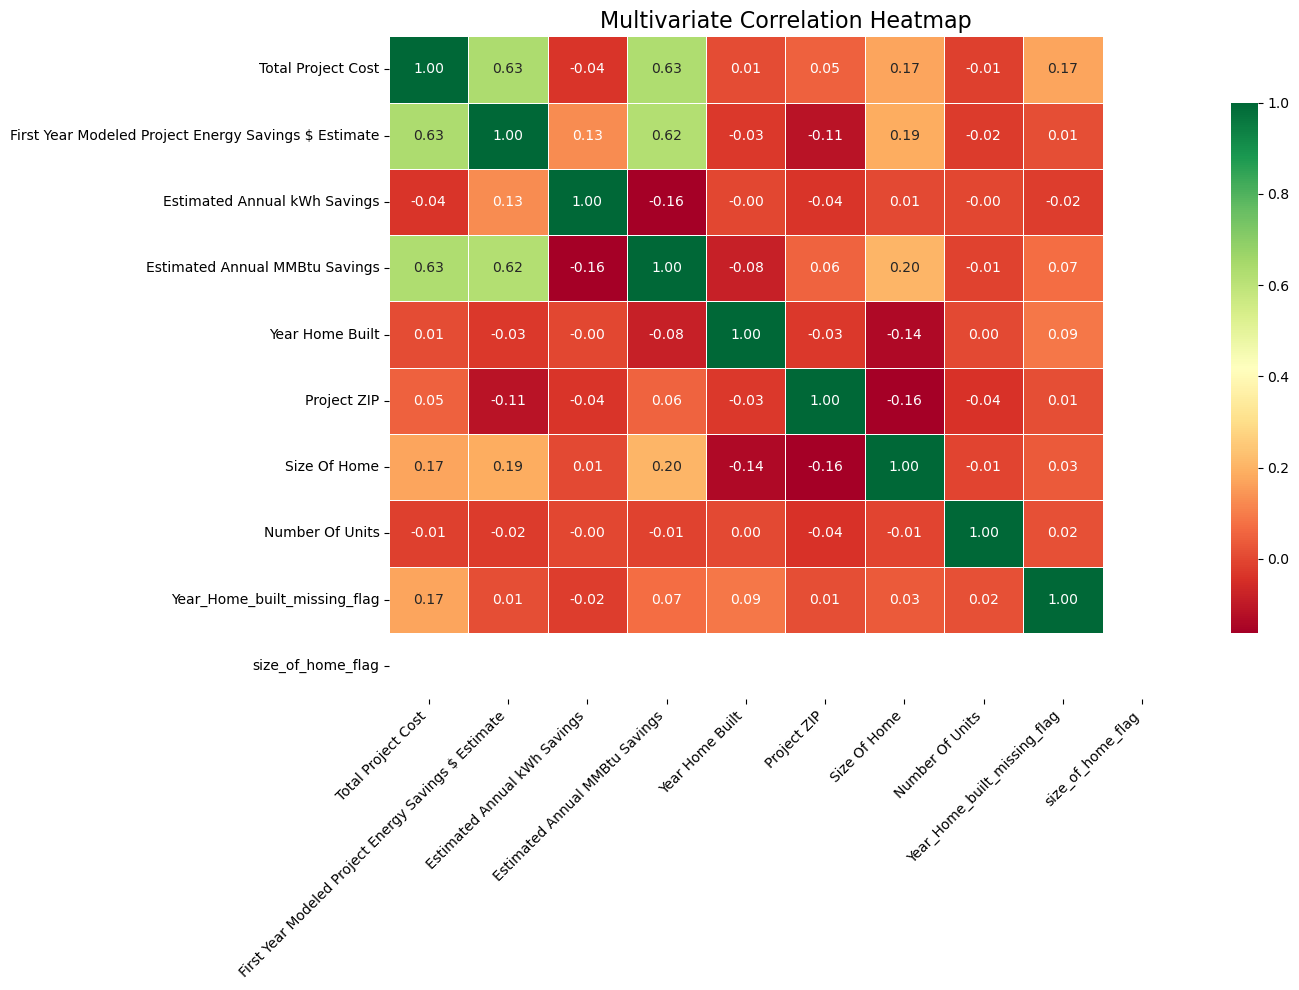

In [8]:
# Correlation Heatmap (Multivariate starter)

priority_cols = [
    'Total Project Cost',
    'First Year Modeled Project Energy Savings $ Estimate',
    'Estimated Annual kWh Savings',
    'Estimated Annual MMBtu Savings',
    'Year Home Built'
]

available_priority = [col for col in priority_cols if col in data.columns]
all_numeric = data.select_dtypes(include=[np.number]).columns.tolist()

# Keep key variables first and add remaining numeric columns if needed
heatmap_cols = available_priority + [col for col in all_numeric if col not in available_priority]

# Limit columns for readability if there are too many numeric features
if len(heatmap_cols) > 12:
    heatmap_cols = heatmap_cols[:12]

corr_df = data[heatmap_cols].corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_df,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
 )
plt.title('Multivariate Correlation Heatmap', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

### Findings 7

The heatmap provides an initial multivariate view of how cost, modeled savings, and utility-based savings interact. Strongly correlated feature groups can guide feature selection and collinearity checks before model training.

### Pairplot Analysis

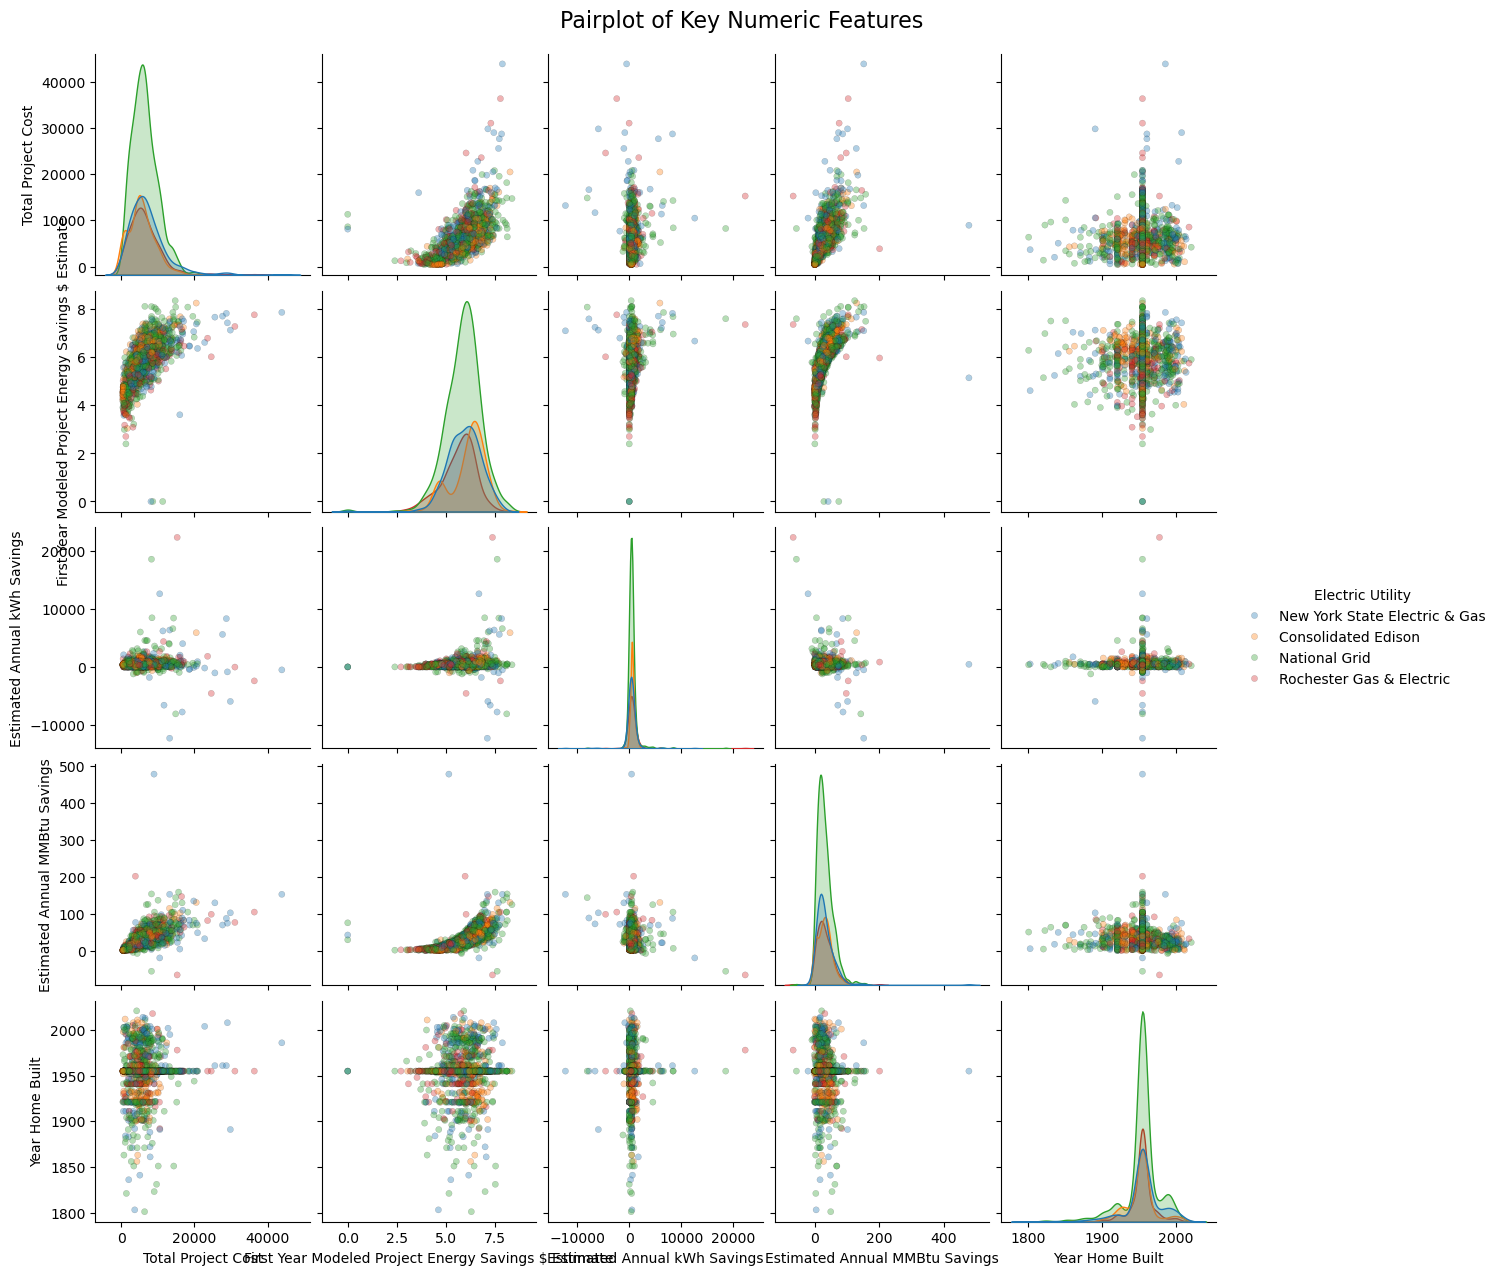

In [9]:
# Pairplot for key multivariate relationships

pairplot_cols = [
    'Total Project Cost',
    'First Year Modeled Project Energy Savings $ Estimate',
    'Estimated Annual kWh Savings',
    'Estimated Annual MMBtu Savings',
    'Year Home Built'
 ]

pairplot_cols = [col for col in pairplot_cols if col in data.columns]

# Optional hue with limited categories for readability
hue_col = None
if 'Electric Utility' in data.columns:
    top_utils = data['Electric Utility'].value_counts().head(4).index
    pairplot_df = data[data['Electric Utility'].isin(top_utils)][pairplot_cols + ['Electric Utility']].dropna().copy()
    if pairplot_df['Electric Utility'].nunique() > 1:
        hue_col = 'Electric Utility'
else:
    pairplot_df = data[pairplot_cols].dropna().copy()

# Downsample for faster rendering if dataset is large
sample_size = 1500
if len(pairplot_df) > sample_size:
    pairplot_df = pairplot_df.sample(sample_size, random_state=42)

sns.pairplot(
    pairplot_df,
    vars=pairplot_cols,
    hue=hue_col,
    diag_kind='kde',
    plot_kws={'alpha': 0.35, 's': 20, 'edgecolor': 'black', 'linewidth': 0.2},
    diag_kws={'fill': True}
)
plt.suptitle('Pairplot of Key Numeric Features', y=1.02, fontsize=16)
plt.show()

### Findings 8

The pairplot reveals pairwise trends, spread, and potential non-linear relationships among cost and savings variables. Clustered patterns by electric utility (for top categories) can indicate utility-specific behavior that may be useful for feature engineering later.